# Iris Flower Classification using MLP

### Complete Machine Learning Pipeline

---

# 1️⃣ Problem Definition

Goal:
Predict the **species of an iris flower** using flower measurements.

Features:

| Feature      | Description     |
| ------------ | --------------- |
| sepal_length | length of sepal |
| sepal_width  | width of sepal  |
| petal_length | length of petal |
| petal_width  | width of petal  |

Target Classes:

* Setosa
* Versicolor
* Virginica

Type:

**Multiclass Classification**

Evaluation metrics:

* Accuracy
* Confusion Matrix
* F1 Score

---


# 2️⃣ Import Libraries

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn joblib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 21.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 12.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.3 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 7.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.7 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.8 MB/s eta 0:00:01

In [35]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

sns.set_style("whitegrid")


# 3️⃣ Data Collection (Code Cell)

In [36]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Features:", feature_names)
print("Classes:", target_names)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


# 4️⃣ Convert to DataFrame (Code Cell)

In [37]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].apply(lambda x: target_names[x])

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# 5️⃣ Exploratory Data Analysis (EDA)

## Dataset Shape

In [38]:
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


## Statistical Summary

In [40]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Check Missing Values

In [41]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

## Class Distribution

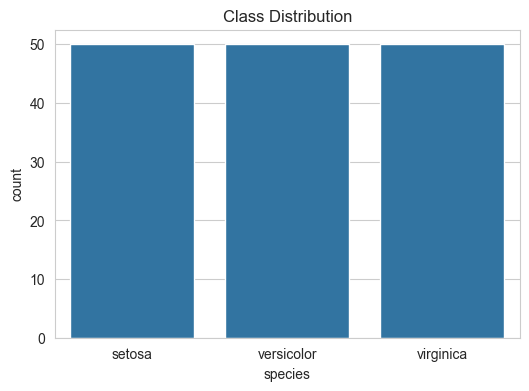

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Class Distribution")
plt.show()

## Pair Plot

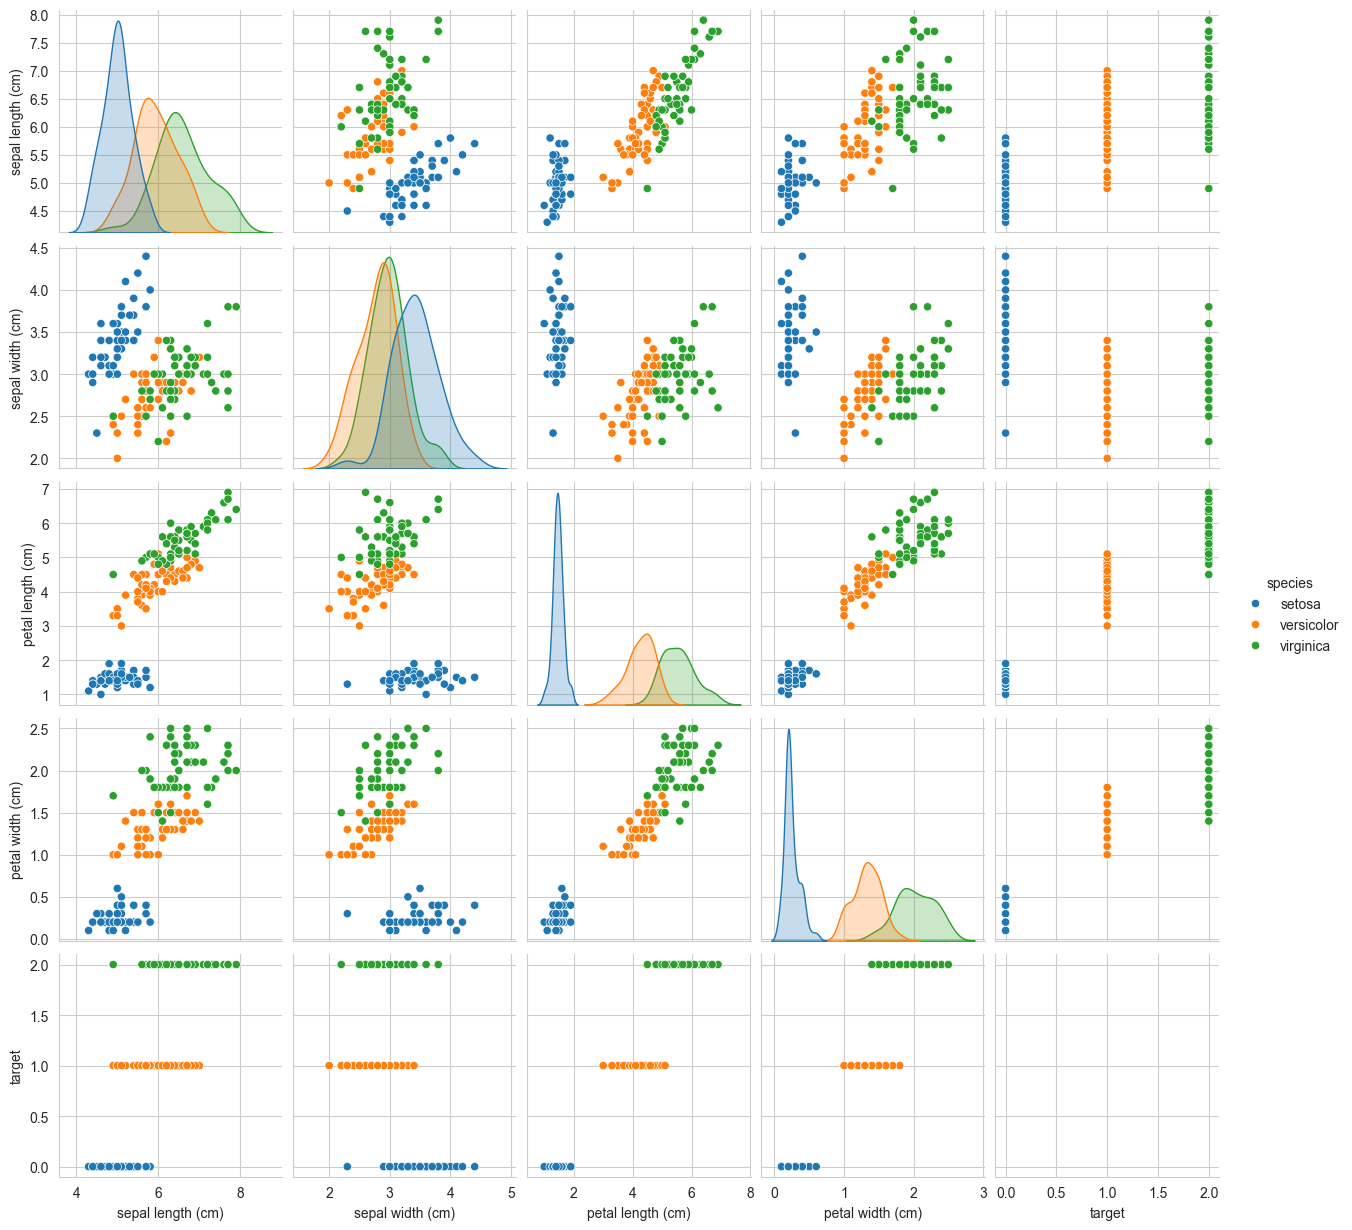

In [43]:
sns.pairplot(df, hue="species")
plt.show()

# 6️⃣ Data Cleaning

In [44]:
print("Duplicate rows:", df.duplicated().sum())

# Result:
# ✔ No duplicates
# ✔ No missing values

Duplicate rows: 1


# 7️⃣ Train Test Split (Code Cell)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (120, 4)
Testing samples: (30, 4)


# 8️⃣ Data Preprocessing (Scaling)

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9️⃣ Model Selection

We use:

**MLPClassifier**

Architecture:

```
Input Layer: 4 neurons
Hidden Layer: 10 neurons
Output Layer: 3 neurons
```

# 🔟 Model Training

In [47]:
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=3000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed")


Model training completed


# 11️⃣ Model Evaluation

## Predictions

In [48]:
y_pred = model.predict(X_test)

## Accuracy

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))

Accuracy: 0.9667


## Confusion Matrix

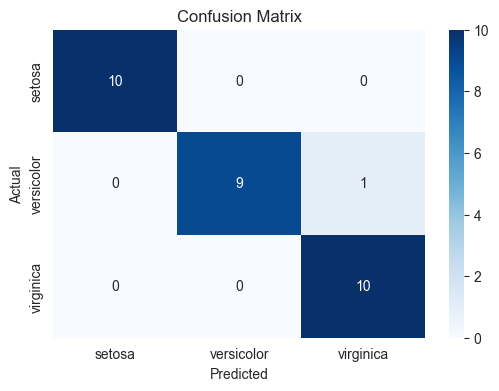

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## Classification Report


In [51]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# 12️⃣ Model Validation (Cross Validation)

In [52]:
scaler_cv = StandardScaler()
X_scaled = scaler_cv.fit_transform(X)

model_cv = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=3000,
    random_state=42
)

scores = cross_val_score(model_cv, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


Cross Validation Scores: [1.         0.96666667 0.96666667 0.93333333 0.96666667]
Average Accuracy: 0.9666666666666668


# 13️⃣ Save Model

In [53]:
joblib.dump(model, "mlp_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully


# 14️⃣ Load Model

In [54]:
loaded_model = joblib.load("mlp_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")


# 15️⃣ Test Prediction

In [55]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print("Predicted Flower Species:", target_names[prediction][0])


Predicted Flower Species: setosa



# 16️⃣ FastAPI Deployment (Separate File)

Save as **app.py**

```python
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("mlp_model.pkl")
scaler = joblib.load("scaler.pkl")

labels = ["Setosa", "Versicolor", "Virginica"]

@app.get("/")
def home():
    return {"message": "Iris Flower Prediction API"}

@app.get("/predict")
def predict(sepal_length: float,
            sepal_width: float,
            petal_length: float,
            petal_width: float):

    data = np.array([[sepal_length,
                      sepal_width,
                      petal_length,
                      petal_width]])

    data = scaler.transform(data)

    prediction = model.predict(data)[0]

    return {"prediction": labels[prediction]}
```

Run:

```bash
uvicorn app:app --reload
```

Open:

```
http://127.0.0.1:8000/docs
```

---



# 17️⃣ Project Structure

```
iris_mlp_project
│
├── iris_mlp.ipynb
├── mlp_model.pkl
├── scaler.pkl
├── app.py
├── requirements.txt
```


# 18️⃣ requirements.txt

```
numpy
pandas
matplotlib
seaborn
scikit-learn
fastapi
uvicorn
joblib
```

Install:

```
pip install -r requirements.txt
```

---

# Final ML Pipeline

```
Problem Definition
        ↓
Data Collection
        ↓
EDA
        ↓
Data Cleaning
        ↓
Preprocessing
        ↓
Train/Test Split
        ↓
Model Training
        ↓
Evaluation
        ↓
Cross Validation
        ↓
Model Saving
        ↓
Deployment
```
